In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("amazon_reviews.csv")


In [29]:
print(data.head())

                               reviewId  \
0  cfb2c5ce-5bd1-4511-bea3-c4a18f9f61ec   
1  a46c3046-7006-4140-88fa-506230eefbe5   
2  74fa6e0a-fe28-4898-a131-39bb69e5ca2d   
3  4bbc9dd6-3fbd-49f0-b7a8-8a3dda749a8a   
4  90a315d8-1d83-4d5b-9372-334bc26d4a29   

                                            userName  \
0  Micro-Penis-Rodney “MicroPenis.RodneyChitwood”...   
1                                    Danielle Goebel   
2                                     Thulile Sabelo   
3                                        Kody Fields   
4                                           Patricia   

                                             content  score  thumbsUpCount  \
0  Great services. I love it almost as much as I ...      5              0   
1  after I filter my search it wont let me click ...      1              0   
2                                   Too many adverts      2              0   
3                                          fantastic      5              0   
4  i have been

In [30]:
print(data.columns)

Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')


In [31]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87445 entries, 0 to 87444
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              87445 non-null  object
 1   userName              87439 non-null  object
 2   content               87439 non-null  object
 3   score                 87445 non-null  int64 
 4   thumbsUpCount         87445 non-null  int64 
 5   reviewCreatedVersion  77270 non-null  object
 6   at                    87445 non-null  object
 7   appVersion            77270 non-null  object
dtypes: int64(2), object(6)
memory usage: 5.3+ MB
None


In [32]:
print(data.isnull().sum())

reviewId                    0
userName                    6
content                     6
score                       0
thumbsUpCount               0
reviewCreatedVersion    10175
at                          0
appVersion              10175
dtype: int64


In [33]:
data = data.dropna()

In [34]:
print(data.shape)

(77262, 8)


In [35]:
print(data.columns)

Index(['reviewId', 'userName', 'content', 'score', 'thumbsUpCount',
       'reviewCreatedVersion', 'at', 'appVersion'],
      dtype='object')


In [36]:
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\priya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
stemmer = PorterStemmer()

stop_words = set(stopwords.words('english'))

def clean_review(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z]',' ',text)

    words = text.split()

    words = [stemmer.stem(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)

In [38]:
data['clean_review'] = data['content'].apply(clean_review)

In [39]:
print(data[['content','clean_review']].head())

                                             content  \
1  after I filter my search it wont let me click ...   
2                                   Too many adverts   
3                                          fantastic   
4  i have been with Amazon for 18 years with 2 ac...   
5                 happy with everything good service   

                                        clean_review  
1  filter search wont let click anyth mean cant f...  
2                                        mani advert  
3                                            fantast  
4  amazon year account cannot without amazon yeah...  
5                          happi everyth good servic  


In [40]:
print(data.head())

                               reviewId         userName  \
1  a46c3046-7006-4140-88fa-506230eefbe5  Danielle Goebel   
2  74fa6e0a-fe28-4898-a131-39bb69e5ca2d   Thulile Sabelo   
3  4bbc9dd6-3fbd-49f0-b7a8-8a3dda749a8a      Kody Fields   
4  90a315d8-1d83-4d5b-9372-334bc26d4a29         Patricia   
5  be312afd-3957-49f4-b266-f34d07cb3c80         Margaret   

                                             content  score  thumbsUpCount  \
1  after I filter my search it wont let me click ...      1              0   
2                                   Too many adverts      2              0   
3                                          fantastic      5              0   
4  i have been with Amazon for 18 years with 2 ac...      5              0   
5                 happy with everything good service      5              0   

  reviewCreatedVersion                   at   appVersion  \
1          32.10.1.100  2026-05-25 08:11:21  32.10.1.100   
2           32.9.0.100  2026-05-25 07:33:33   32.9

In [41]:
data = data[data['score'] != 3]

data['label'] = data['score'].apply(
    lambda x: 1 if x <= 2 else 0
)

In [42]:
print(data[['score','label']].head())

   score  label
1      1      1
2      2      1
3      5      0
4      5      0
5      5      0


In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(
    data['clean_review']
)

y = data['label']

In [44]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [46]:
y_pred = model.predict(X_test)

In [47]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:",accuracy)

Accuracy: 0.9150123631225715


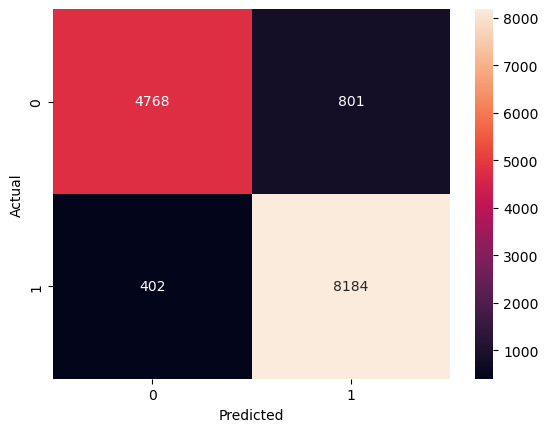

In [48]:
from sklearn.metrics import confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
from sklearn.metrics import classification_report

print(
classification_report(
y_test,
y_pred
)
)

              precision    recall  f1-score   support

           0       0.92      0.86      0.89      5569
           1       0.91      0.95      0.93      8586

    accuracy                           0.92     14155
   macro avg       0.92      0.90      0.91     14155
weighted avg       0.92      0.92      0.91     14155



In [50]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train,y_train)

nb_pred = nb_model.predict(X_test)

from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(
    y_test,
    nb_pred
)

print("Naive Bayes Accuracy:",
      nb_accuracy)

Naive Bayes Accuracy: 0.9013776050865419


In [51]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score  # Added missing import

# Create RandomForest model with reduced complexity to speed up training
rf_model = RandomForestClassifier(
    n_estimators=50,  # Reduced from 100 to speed up training
    max_depth=10,     # Added max_depth to limit tree complexity
    n_jobs=-1,        # Use all available CPU cores for parallel processing
    random_state=42
)

# Fit the model (ensure X_train and y_train are defined beforehand)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Calculate accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)

# Print results
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7880607559166373


In [52]:
models = [
"Logistic Regression",
"Naive Bayes","Random Forest"
]

accuracy = [
accuracy,
nb_accuracy,
rf_accuracy
]

comparison = pd.DataFrame(
{
"Model":models,
"Accuracy":accuracy
}
)

print(comparison)

                 Model  Accuracy
0  Logistic Regression  0.915012
1          Naive Bayes  0.901378
2        Random Forest  0.788061


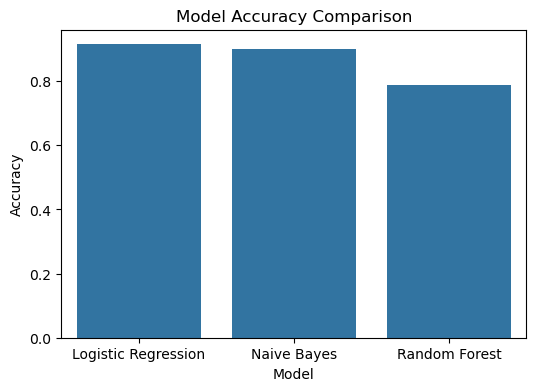

In [53]:
plt.figure(figsize=(6,4))

sns.barplot(
x='Model',
y='Accuracy',
data=comparison
)

plt.title(
'Model Accuracy Comparison'
)

plt.show()

In [54]:
"This project used NLP and Machine Learning to analyze review text. TF-IDF converted text into numerical features, and models like Logistic Regression, Naive Bayes, and Random Forest were compared."

'This project used NLP and Machine Learning to analyze review text. TF-IDF converted text into numerical features, and models like Logistic Regression, Naive Bayes, and Random Forest were compared.'

In [65]:
import pickle
pickle.dump(model,open('review_model.pkl','wb'))

In [66]:
pickle.dump(tfidf,open('tfidf.pkl','wb'))
print("Files saved successfully")

Files saved successfully


In [67]:
review = ["This product is very good"]

review_vector = tfidf.transform(review)

prediction = model.predict(review_vector)

print(prediction)

[0]
